<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [23]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# import importlib
# import cellsweep.celltype_ambient
# importlib.reload(cellsweep.celltype_ambient)
# from cellsweep.celltype_ambient import denoise_count_matrix

# import importlib
# import cellsweep.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# importlib.reload(cs_utils)

# Compare CellBender vs. cellsweep

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [24]:
dataset_name = "hgmm_12k"  # options: pbmc8k, hgmm_12k, kidney_nuclei_10k, melanoma, pbmc_mouse_5k, pbmc33k, simulation1_small_noise, simulation2_high_noise  # for a custom dataset, make a new yaml file with the desired config - see example template at notebooks/config/custom.yaml
alternative_tools = ["cellbender", "soupx", "decontx", "scar"]
rerun_tools = False  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"  # installing scAR: git clone https://github.com/Novartis/scar.git; cd scar; conda env create -f scar-cpu.yml (or scar-gpu.yml)
use_cuda = False  # for CellBender and scAR
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [25]:
# load yaml
yaml_file = os.path.join(cellsweep_dir, "notebooks", "config", f"{dataset_name}.yaml")
cfg = cs_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# raw adata
if cfg.get("adata_raw_file_name") is None:
    if cfg.get("adata_raw_url") is not None:
        cfg["adata_raw_file_name"] = cfg["adata_raw_url"].split("/")[-1]
    # else:
    #     raise ValueError("If adata_raw_file_name is not specified in the config yaml, adata_raw_url must be specified.")

adata_path_raw = f"{data_dir}/{cfg['adata_raw_file_name']}" if cfg['adata_raw_file_name'] is not None else None
if adata_path_raw and not os.path.exists(adata_path_raw) and cfg["adata_raw_url"] is not None:
    !wget -O {adata_path_raw} {cfg["adata_raw_url"]}

matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)

raw_tar_file_dir = None
filtered_tar_file_dir = None

sequencing_technology = cfg["sequencing_technology"]

# set file paths for tools
adata_path_cellsweep = f"{data_dir}/{cfg['adata_path_cellsweep_name']}"
cellsweep_log_file = os.path.join(data_dir, "cellsweep.log")

adata_path_cellbender = f"{data_dir}/{cfg['adata_path_cellbender_name']}"
adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")
cellbender_ckpt = os.path.join(data_dir, "cellbender_ckpt.tar.gz")

soupx_out_prefix = f"{data_dir}/{cfg['soupx_out_prefix_name']}"
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"

decontx_out_prefix = f"{data_dir}/{cfg['decontx_out_prefix_name']}"

adata_path_scar = f"{data_dir}/{cfg['adata_path_scar_name']}"


if dataset_name == "hgmm_12k":    
    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    # # check if raw_tar_file_dir is empty or doesn't exist
    # if rerun_tools and (not os.path.exists(raw_tar_file_dir) or len(os.listdir(raw_tar_file_dir)) == 0) or (not os.path.exists(filtered_tar_file_dir) or len(os.listdir(filtered_tar_file_dir)) == 0):
    adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=cfg["expected_cells"], show=False)
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix

if dataset_name.startswith("simulation"):
    # simulate data
    if not os.path.exists(adata_path_raw) or overwrite:
        adata_raw = simulate_cells(
            G=cfg["G"],
            N=cfg["N"],
            k=cfg["k"],
            markers_per_type=cfg["markers_per_type"],
            marker_boost=cfg["marker_boost"],
            type_proportions=cfg["type_proportions"],
            empty_prob=cfg["empty_prob"],
            alpha=cfg["alpha"],
            beta=cfg["beta"],
            expected_cell_size=cfg["expected_cell_size"],
            noise_logsd_cell=cfg["noise_logsd_cell"],
            noise_logsd_empty=cfg["noise_logsd_empty"],
            dispersion=cfg["dispersion"],
            housekeeping_frac=cfg["housekeeping_frac"],
            hk_logmean=cfg["hk_logmean"],
            hk_logsd=cfg["hk_logsd"],
            rng_seed=42,
        )
        adata_raw.write_h5ad(adata_path_raw)
    else:
        adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)

    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=True)

    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix


# raw and filtered matrix tar files
if cfg["raw_tar_url"] is not None and (rerun_tools or adata_path_raw is None):
    raw_tar_file_name = cfg["raw_tar_url"].split("/")[-1]
    raw_tar_path = os.path.join(matrix_tar_files_dir, raw_tar_file_name)
    if not os.path.exists(raw_tar_path):
        !wget -O {raw_tar_path} {cfg["raw_tar_url"]}
    raw_tar_dir_name = cs_utils.get_tar_top_level_dir(raw_tar_path)
    raw_tar_dir_path = os.path.join(matrix_tar_files_dir, raw_tar_dir_name)
    if not os.path.exists(raw_tar_dir_path):
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    # if folder name doesn't start with "raw_", rename it
    index = raw_tar_dir_name.find("raw_")
    if index != 0:
        raw_tar_dir_name_new = raw_tar_dir_name[index:] if index != -1 else raw_tar_dir_name
        raw_tar_dir_path_new = os.path.join(matrix_tar_files_dir, raw_tar_dir_name_new)
        if not os.path.exists(raw_tar_dir_path_new):
            os.rename(raw_tar_dir_path, raw_tar_dir_path_new)
        raw_tar_dir_name = raw_tar_dir_name_new
        raw_tar_dir_path = raw_tar_dir_path_new


if rerun_tools and raw_tar_file_dir is None:
    if cfg.get('raw_tar_file_dir_suffix') is None:
        raw_tar_file_dir = cs_utils.find_single_branch_leaf_dir(raw_tar_dir_path)
    else:
        raw_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['raw_tar_file_dir_suffix']}"

if cfg["filtered_tar_url"] is not None and rerun_tools:
    filtered_tar_file_name = cfg["filtered_tar_url"].split("/")[-1]
    filtered_tar_path = os.path.join(matrix_tar_files_dir, filtered_tar_file_name)
    if not os.path.exists(filtered_tar_path):
        !wget -O {filtered_tar_path} {cfg["filtered_tar_url"]}
    filtered_tar_dir = cs_utils.get_tar_top_level_dir(filtered_tar_path)
    filtered_tar_dir_path = os.path.join(matrix_tar_files_dir, filtered_tar_dir)
    if not os.path.exists(filtered_tar_dir_path):
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
    # if folder name doesn't start with "filtered_", rename it
    index = filtered_tar_dir.find("filtered_")
    if index != 0:
        filtered_tar_dir_name_new = filtered_tar_dir[index:] if index != -1 else filtered_tar_dir
        filtered_tar_dir_path_new = os.path.join(matrix_tar_files_dir, filtered_tar_dir_name_new)
        if not os.path.exists(filtered_tar_dir_path_new):
            os.rename(filtered_tar_dir_path, filtered_tar_dir_path_new)
        filtered_tar_dir = filtered_tar_dir_name_new
        filtered_tar_dir_path = filtered_tar_dir_path_new

if rerun_tools and filtered_tar_file_dir is None:
    if cfg.get('filtered_tar_file_dir_suffix') is None:
        filtered_tar_file_dir = cs_utils.find_single_branch_leaf_dir(filtered_tar_dir_path)
    else:
        filtered_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['filtered_tar_file_dir_suffix']}"

# lay out parameters
model_pkl = cfg["model_pkl"]
celltypist_convert = cfg["celltypist_convert"]
celltypist_map_file = cfg["celltypist_map_file"]
cellsweep_max_iter = cfg["cellsweep_max_iter"]
cellsweep_beta = cfg["cellsweep_beta"]
cellsweep_init_alpha = cfg["cellsweep_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

cellsweep_matrix_url = cfg["cellsweep_matrix_url"]
cellbender_matrix_filtered_url = cfg["cellbender_matrix_filtered_url"]
cellbender_ckpt_url = cfg["cellbender_ckpt_url"]
soupx_matrix_url = cfg["soupx_matrix_url"]
decontx_matrix_url = cfg["decontx_matrix_url"]
scar_matrix_url = cfg["scar_matrix_url"]

15:17:25 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
15:17:25 - INFO - Multiple genomes found in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5': ['hg19', 'mm10']. Loading each separately.
15:17:25 - INFO - Loading genome 'hg19' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
15:17:27 - INFO - Loading genome 'mm10' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/home/j

UMI cutoff for expected cells (12820): 3084.00
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/matrix_tar_files/combined/raw_gene_bc_matrices/combined'. Skipping write.
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/matrix_tar_files/combined/filtered_gene_bc_matrices/combined'. Skipping write.


## Raw

In [26]:
if adata_path_raw is not None and os.path.exists(adata_path_raw):
    adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
elif raw_tar_file_dir is not None and os.path.exists(raw_tar_file_dir):
    adata_raw = cs_utils.load_adata(raw_tar_file_dir, verbose=verbose)
else:
    raise ValueError("No raw data found.")
adata_raw.var_names_make_unique()

15:17:39 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
15:17:39 - INFO - Multiple genomes found in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5': ['hg19', 'mm10']. Loading each separately.
15:17:39 - INFO - Loading genome 'hg19' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
15:17:40 - INFO - Loading genome 'mm10' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_u

## Knee plot - use this output to estimate umi_cutoff

UMI cutoff for expected cells (12820): 3084.00


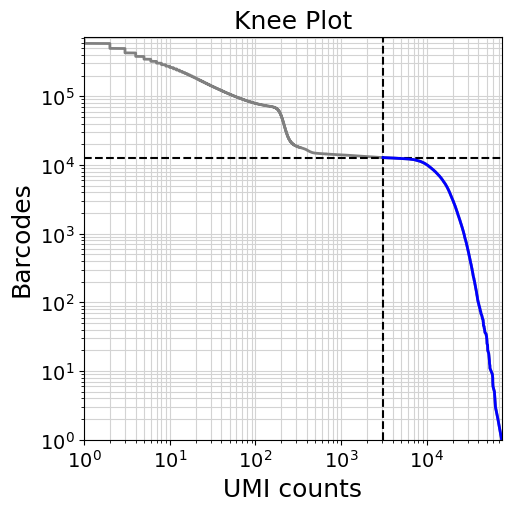

In [27]:
umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, transpose=True, out_path=os.path.join(out_dir, "knee_plot.png"))

In [28]:
# umi_cutoff = 0  #!!! optionally update from knee plot
if not dataset_name.startswith("simulation"):
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [29]:
if dataset_name == "hgmm_12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cs_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=fraction_doublet, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

hg19_RPS2: 288402.0
hg19_RPL10: 153516.0
hg19_RPS18: 152179.0
hg19_RPS4X: 145981.0
hg19_RPS6: 125242.0
hg19_RPL13: 115657.0
hg19_RPS19: 111334.0
hg19_RPS14: 111253.0
hg19_RPL15: 110307.0
hg19_RPLP1: 108770.0


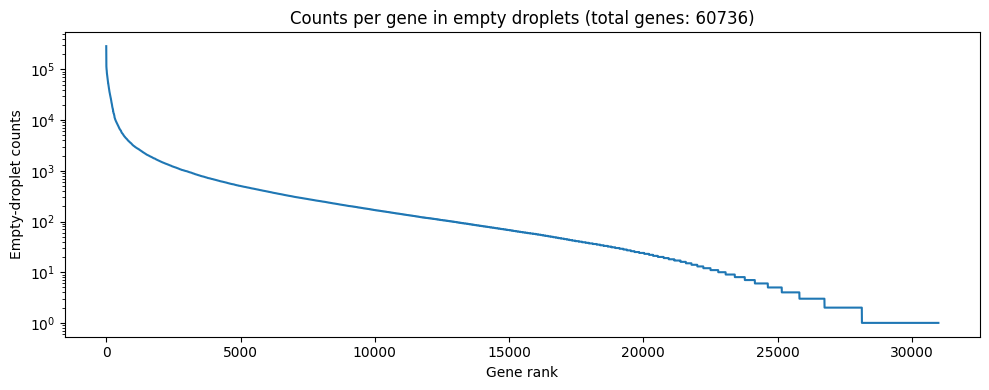

In [30]:
cs_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cs_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## cellsweep

In [31]:
%%time
if not os.path.exists(adata_path_cellsweep) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata.obs.columns:
        adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
    _ = denoise_count_matrix(adata, init_alpha=cellsweep_init_alpha, beta = cellsweep_beta, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)

CPU times: user 198 μs, sys: 0 ns, total: 198 μs
Wall time: 149 μs


In [32]:
adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep.var_names_make_unique()
print(f"Counts are less than or equal check for cellsweep: {cs_utils.check_counts_less_equal(adata_raw, adata_cellsweep)}")

Counts are less than or equal check for cellsweep: True


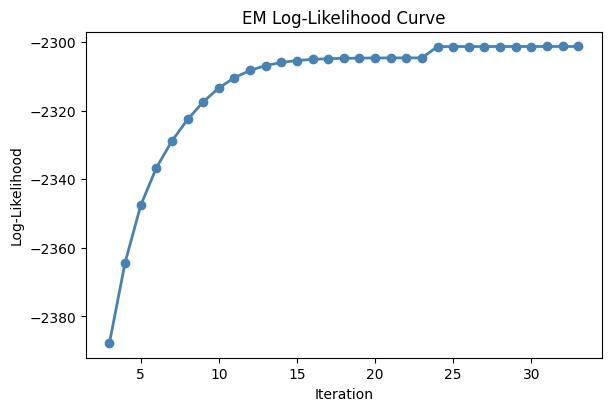

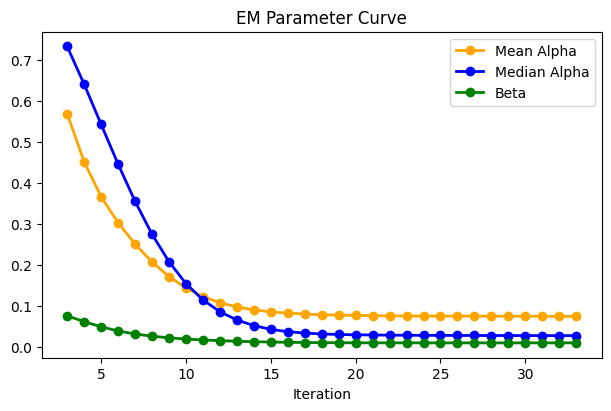

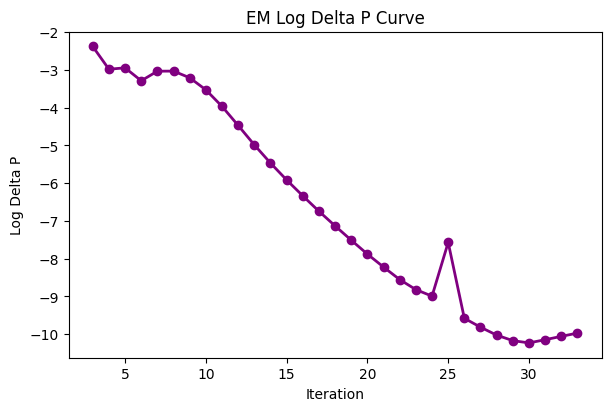

In [33]:
# plot cellsweep likelihood over epochs
if os.path.exists(cellsweep_log_file):
    cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)
    cs_utils.plot_cellsweep_parameters_over_epochs(log_path=cellsweep_log_file, show=True)
    cs_utils.plot_cellsweep_delta_p_over_epochs(log_path=cellsweep_log_file, show=True)

# # plot ambient_hat vs empty fraction
# cs_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellsweep, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellsweep_ambient_hat_vs_empty_fraction.png"))

# # plot knee plot colored by alpha_hat
# adata_denoised = adata_cellsweep.copy()
# adata_denoised.layers["denoised"] = adata_denoised.X.copy()
# adata_denoised.X = adata_denoised.layers["raw"].copy()
# cs_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
# cs_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
# adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
# adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
# adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

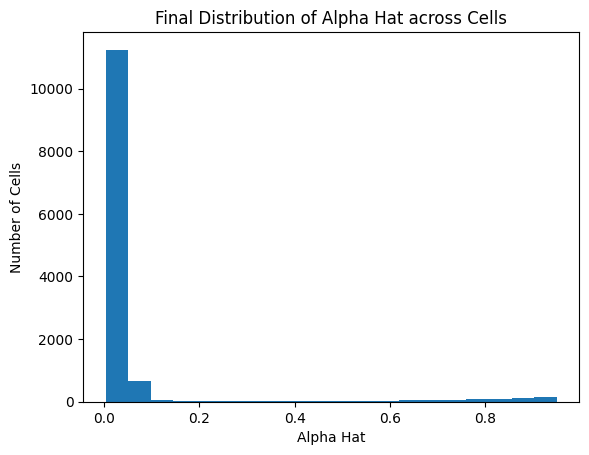

In [34]:
plt.figure()
plt.hist(adata_cellsweep.obs['alpha_hat'], bins=20)
plt.xlabel('Alpha Hat')
plt.ylabel('Number of Cells')
plt.title('Final Distribution of Alpha Hat across Cells')
plt.show()

In [35]:
adata_cellsweep.obs['alpha_hat'].describe()

count    12820.000000
mean         0.074454
std          0.178416
min          0.003717
25%          0.020723
50%          0.027362
75%          0.036588
max          0.949333
Name: alpha_hat, dtype: float64

In [36]:
(adata_cellsweep.obs['alpha_hat'] > 0.5).sum()

np.int64(686)

## CellBender (v0.3.0)

In [37]:
%%time
if "cellbender" in alternative_tools and (not os.path.exists(adata_path_cellbender_filtered) or overwrite):
     if rerun_tools or cellbender_matrix_filtered_url is None:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          ckpt_out_path = cellbender_ckpt.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 85 μs, sys: 6 μs, total: 91 μs
Wall time: 75.6 μs


In [38]:
adata_cellbender = None
if "cellbender" in alternative_tools:
    adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata_cellbender.var_names_make_unique()
    print(f"Counts are less than or equal check for CellBender: {cs_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [39]:
# %%time
if "soupx" in alternative_tools and (soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or soupx_matrix_url is None:
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

In [40]:
adata_soupx = None
if "soupx" in alternative_tools:
    adata_soupx = cs_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    print(f"Counts are less than or equal check for SoupX: {cs_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [41]:
%%time
if "decontx" in alternative_tools and (decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or decontx_matrix_url is None:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 49 μs, sys: 4 μs, total: 53 μs
Wall time: 60.3 μs


In [42]:
adata_decontx = None
if "decontx" in alternative_tools:
    adata_decontx = cs_utils.load_adata(decontx_out_prefix)
    adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
    adata_decontx.var_names_make_unique()
    print(f"Counts are less than or equal check for DecontX: {cs_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [43]:
%%time
%env MPLBACKEND=
if "scar" in alternative_tools and (adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite)):
     if rerun_tools or scar_matrix_url is None:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellsweep_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            -p {scar_prob} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

env: MPLBACKEND=
CPU times: user 505 μs, sys: 0 ns, total: 505 μs
Wall time: 522 μs


In [44]:
adata_scar = None
if "scar" in alternative_tools:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cs_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for scAR: False


# Analysis

In [45]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellsweep=adata_cellsweep,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    if adata is None:
        continue
    print(f"{key}:\n{adata}\n\n")

raw:
AnnData object with n_obs × n_vars = 737280 × 60736
    obs: 'is_empty', 'hg19_total_counts', 'mm10_total_counts', 'genome', 'celltype', 'is_doublet'
    var: 'gene_ids', 'genome', 'empty_counts'


cellsweep:
AnnData object with n_obs × n_vars = 12820 × 60736
    obs: 'is_empty', 'hg19_total_counts', 'mm10_total_counts', 'genome', 'celltype', 'is_doublet', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'genome', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'raw'


cellbender:
AnnData object with n_obs × n_vars = 14146 × 60736
    var: 'gene_ids', 'feature_types', 'genome'


soupx:
AnnData object with n_obs × n_vars = 12820 × 60736


decontx:
AnnData object with n_obs × n_vars = 12820 × 60736


scar:
AnnData object with n_obs × n_vars = 12820 × 60736
    var: 'gene_ids', 'feature_types'
    uns: 'ambient_profile_Gene Expression', 'ambient_profile_all'


## Simulations

In [46]:
if dataset_name.startswith("simulation"):

    def get_top_contaminated_markers(adata, n_top):
        marker_sets = adata.uns["marker_sets"]

        # mask for real cells only
        cell_mask = ~adata.obs["is_empty"].values
        X_noise = adata.layers["noise"][cell_mask].toarray()
        X_real  = adata.layers["real"][cell_mask].toarray()

        # --- collect contamination for all markers globally ---
        marker_info = []  # (gene, cell_type, contamination)

        for i, markers in enumerate(marker_sets):
            cell_type = f"Type_{i}"
            for g in markers:
                noise_sum = X_noise[:, g].sum()
                real_sum  = X_real[:, g].sum()
                total = noise_sum + real_sum

                if total == 0:
                    contamination = 0.0
                else:
                    contamination = noise_sum / total

                marker_info.append((g, cell_type, contamination))

        # --- sort globally by contamination ---
        marker_info.sort(key=lambda x: x[2], reverse=True)

        # --- select top-N globally ---
        top_markers = marker_info[:n_top]

        markers = []
        # --- regroup by cell type ---
        result = defaultdict(list)
        for g, cell_type, _ in top_markers:
            markers.append(g)
            result[cell_type].append(f"Gene_{g}")

        return dict(result), markers

    marker_mat = adata_dict["raw"].uns["marker_sets"]
    markers = marker_mat.flatten().tolist()
    marker_genes, _ = get_top_contaminated_markers(adata_dict["raw"], n_top=20)

    cell_sets = [
        set(adata.obs_names)
        for key, adata in adata_dict.items()
        if adata is not None and key != "raw"
    ]
    cells_common_to_all_tools = set.intersection(*cell_sets)

    for adata_name, adata in adata_dict.items():
        if adata_name == "raw" or adata is None:
            continue

        adata = adata.copy()
        adata = adata[adata.obs_names.isin(cells_common_to_all_tools)].copy()
        cs_utils.evaluate_simulation_denoising(adata_processed = adata, adata_real = adata_dict["raw"].copy(), tool = adata_name, out_base = f"{out_dir}/{adata_name}_denoising_evaluation", show=True)

        adata_predicted_signal = adata.copy()
        adata_raw_tmp = adata_dict["raw"].copy()
        adata_predicted_signal, adata_raw_tmp = cs_utils.take_adata_cell_gene_intersection(adata_predicted_signal, adata_raw_tmp)

        adata_predicted_noise = adata_predicted_signal.copy()
        adata_predicted_noise.X = adata_raw_tmp.X - adata_predicted_signal.X  # noise = raw - signal
        
        adata_true_noise = adata_raw_tmp.copy()
        adata_true_noise.X = adata_raw_tmp.layers["noise"].copy()  # true noise

        adata_true_signal = adata_raw_tmp.copy()
        adata_true_signal.X = adata_raw_tmp.layers["real"].copy()

        show = (adata_name == "cellsweep")
        
        # noise plots
        density_type_matrix = "scatter_with_kde" if adata_predicted_noise.X.size < 1e6 else "scatter_with_density"
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="matrix", density_type=density_type_matrix, scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted matrix noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_matrix_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted cell noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_cell_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted gene noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_gene_expression_scatterplot.png"), show=show)

        # signal-noise plots
        def plot_signal_noise_scatter(adata_true_signal, adata_predicted_signal, adata_true_noise, adata_predicted_noise):
            X_true = adata_true_signal.X
            X_noise = adata_predicted_noise.X
            X_true_noise = adata_true_noise.X

            noise_diff = np.asarray((X_true_noise - X_noise).toarray()) if sp.issparse(X_true_noise) else (X_true_noise - X_noise)
            total_noise = np.maximum(noise_diff, 0).sum(axis=1)

            X_signal = X_true + np.minimum(np.asarray(noise_diff), 0)
            adata_signal_tmp = ad.AnnData(
                X=X_signal,
                obs=adata_predicted_signal.obs.copy(),
                var=adata_predicted_signal.var.copy()
            )
            if sp.issparse(adata_signal_tmp.X):
                total_signal = np.asarray(adata_signal_tmp.X.sum(axis=1)).ravel()
            else:
                total_signal = adata_signal_tmp.X.sum(axis=1)
        
            # cs_utils.plot_histogram_simulation(X_true_noise, data_type="matrix", log_scale=True, title="True noise")
            # cs_utils.plot_histogram_simulation(X_true_noise, data_type="cell", log_scale=False, title="True noise")
            cs_utils.plot_histogram_simulation(noise_diff, data_type="matrix", log_scale=True, title="Noise difference (true - predicted)")

            adata_predicted_signal.obs["total_signal"] = total_signal
            adata_predicted_signal.obs["total_noise"] = total_noise

            adata_raw_tmp.obs["total_noise"] = np.asarray(X_true_noise.sum(axis=1)).ravel() 
            adata_raw_tmp.obs["total_signal"] = np.asarray(X_true.sum(axis=1)).ravel() 

            out_path = os.path.join(out_dir, f"cross_species_joint_scatterplot_total_signal_vs_total_noise_{adata_name}.png")
            cs_utils.plot_cross_species_joint_scatterplot(adata_raw_tmp, adata_predicted_signal, processed_name=adata_name, x_name="total_signal", y_name="total_noise", genome_column=None, marginal_color_number=2, x_axis="total_signal", y_axis="total_noise", marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=out_path, show=True)
            
        
        plot_signal_noise_scatter(adata_true_signal, adata_predicted_signal, adata_true_noise, adata_predicted_noise)
        plot_signal_noise_scatter(adata_true_signal[:, markers].copy(), adata_predicted_signal[:, markers].copy(), adata_true_noise[:, markers].copy(), adata_predicted_noise[:, markers].copy())

        if "celltype" not in adata_predicted_signal.obs.columns:
            adata_predicted_signal.obs = adata_predicted_signal.obs.merge(adata_raw_tmp.obs[["celltype"]], left_index=True, right_index=True, how="left")

        out_path_raw = os.path.join(out_dir, f"dotplot_raw.png")
        out_path_processed = os.path.join(out_dir, f"dotplot_{adata_name}.png")
        plot_raw = (adata_name == "cellsweep")
        cs_utils.make_raw_and_processed_dotplots(adata_raw_tmp, adata_predicted_signal, marker_genes, plot_raw=plot_raw, cluster_column='celltype', log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot", title_processed=f"{adata_name} Processed Data Dotplot", out_path_raw=out_path_raw, out_path_processed=out_path_processed)

        # del adata_raw_tmp
        # del adata_predicted_signal
        # del adata_predicted_noise
        # del adata_true_signal
        # del adata_true_noise

## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  style

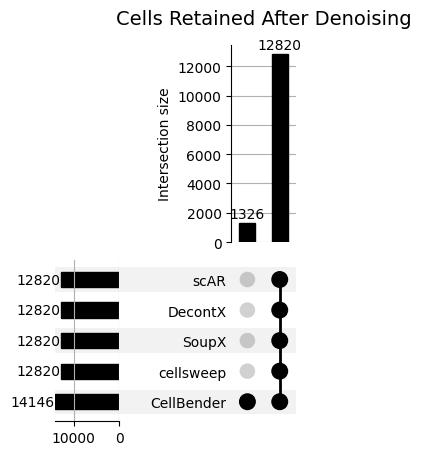

In [26]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellsweep": set(adata_cellsweep.obs_names),
    "CellBender": set(adata_cellbender.obs_names) if adata_cellbender is not None else None,
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cs_utils.make_upset_plot(upset_data_dict, title="Cells Retained After Denoising", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Updated knee plots

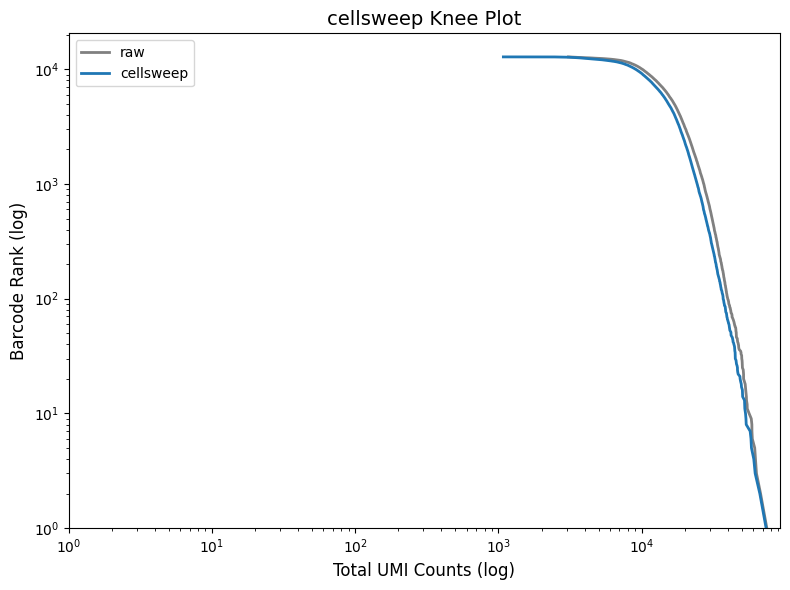

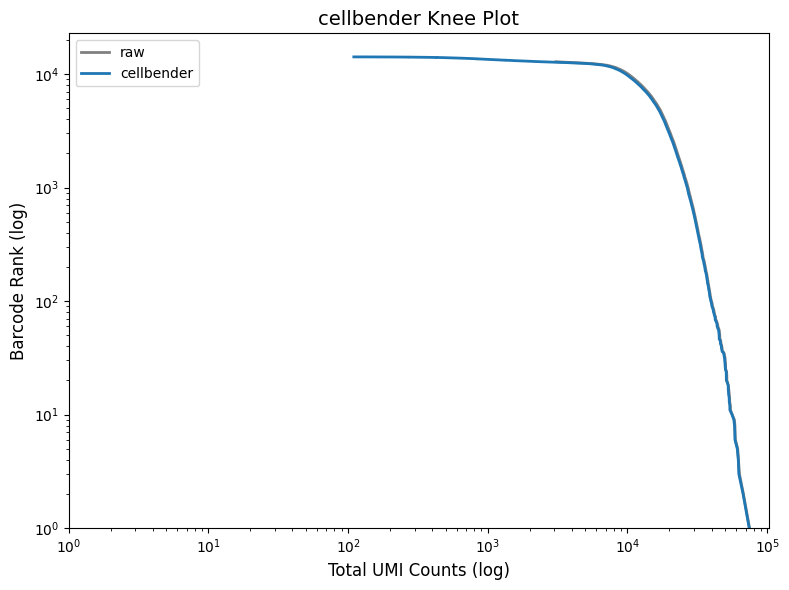

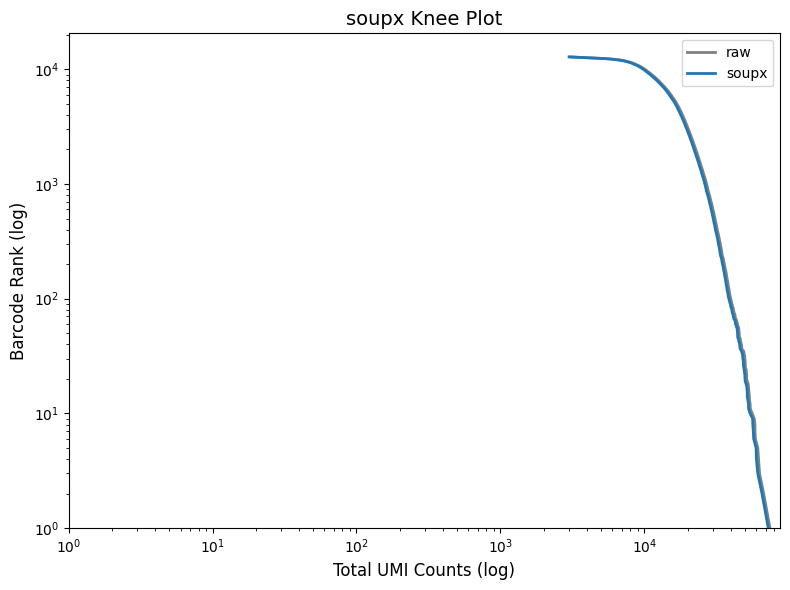

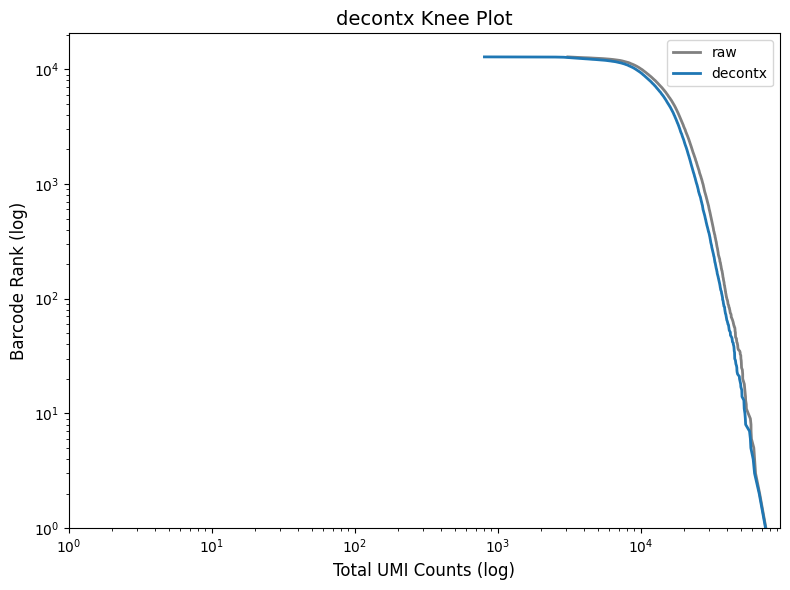

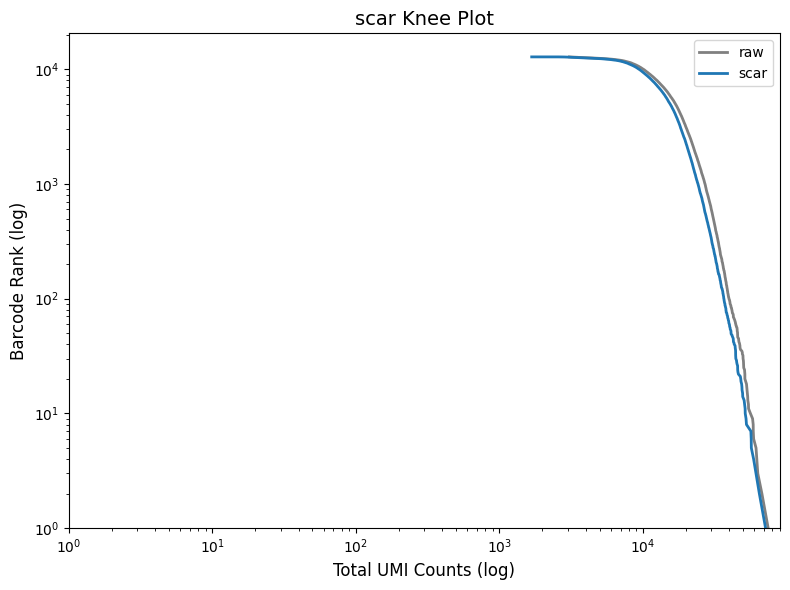

In [27]:
for tool, adata in adata_dict.items():
    if adata is None or tool == "raw":
        continue
    cs_utils.plot_knee_multi([adata_dict["raw"], adata], labels=["raw", tool], title=f"{tool} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot.png"))

## Scatterplot of cell x gene expression differences

In [ ]:
adata_dict_nonempty_length = len([adata for adata in adata_dict.values() if adata is not None])
num_iterations = adata_dict_nonempty_length * (adata_dict_nonempty_length - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    if val1 is None or val2 is None:
        continue
    
    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellsweep", "cellbender"} and key2 in {"raw", "cellsweep", "cellbender"})
    # Scatterplot by matrix, cell, and gene
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # Histogram of differences from raw by matrix, cell, and gene
    # cs_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    cs_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    cs_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # Histogram of cosine similarity by cell and gene
    cs_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    cs_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)
    
    iteration += 1

In [ ]:
if dataset_name.startswith("simulation"):
    sys.exit()

## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

In [67]:
adata_raw.obs.head()

,is_empty,hg19_total_counts,mm10_total_counts,genome,celltype,is_doublet
AAACCTGAGAAACCAT-1,True,4.0,10.0,mm10,mm10,True
AAACCTGAGAAACCGC-1,True,0.0,3.0,mm10,mm10,False
AAACCTGAGAAACCTA-1,True,6.0,4.0,hg19,hg19,True
AAACCTGAGAAACGAG-1,True,1.0,0.0,hg19,hg19,False
AAACCTGAGAAACGCC-1,True,1.0,17.0,mm10,mm10,False


Contamination stats for raw:
Mean human contamination counts (mouse reads in human cells): 2.21%
Mean mouse contamination counts (human reads in mouse cells): 3.14%
90th percentile human contamination counts (mouse reads in human cells): 9.09%
90th percentile mouse contamination counts (human reads in mouse cells): 11.11%
Total contamination across all human cells: 1,583,215
Total contamination across all mouse cells: 2,003,256
Total signal across all human cells: 120,578,448
Total signal across all mouse cells: 66,950,980
-----
Contamination stats for cellsweep:
Mean human contamination counts (mouse reads in human cells): 0.02%
Mean mouse contamination counts (human reads in mouse cells): 0.03%
90th percentile human contamination counts (mouse reads in human cells): 0.03%
90th percentile mouse contamination counts (human reads in mouse cells): 0.05%
Total contamination across all human cells: 19,328
Total contamination across all mouse cells: 21,468
Total signal across all human cell

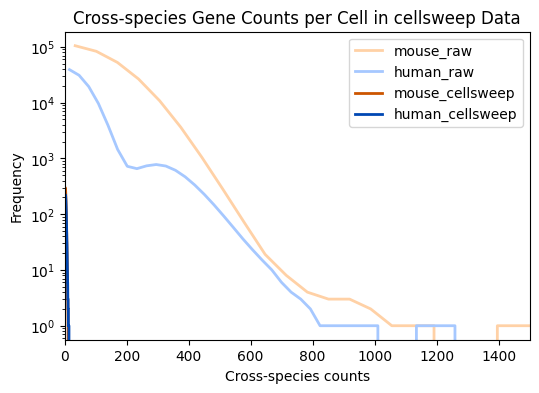

cellsweep human cell mouse gene contamination AUC: 958.6422208249569
cellsweep mouse cell human gene contamination AUC: 1279.016795605421


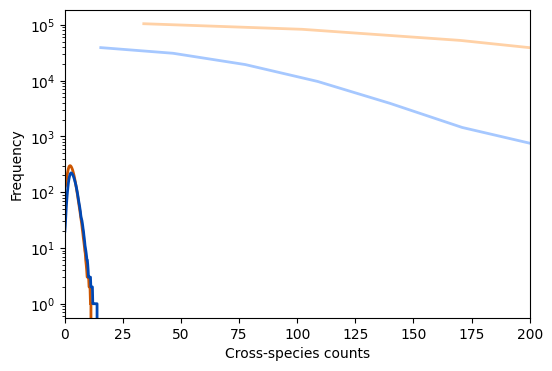

Contamination stats for cellbender:
Mean human contamination counts (mouse reads in human cells): 0.06%
Mean mouse contamination counts (human reads in mouse cells): 0.06%
90th percentile human contamination counts (mouse reads in human cells): 0.03%
90th percentile mouse contamination counts (human reads in mouse cells): 0.07%
Total contamination across all human cells: 86,770
Total contamination across all mouse cells: 54,246
Total signal across all human cells: 115,836,817
Total signal across all mouse cells: 64,884,898
Human cell contamination removed: 1,496,445 (94.52% of raw)
Mouse cell contamination removed: 1,949,010 (97.29% of raw)
Human cell signal remaining: 115,836,817 (96.07% of raw)
Mouse cell signal remaining: 64,884,898 (96.91% of raw)
-----
cellbender human cell mouse gene contamination AUC: 136480.39999999997
cellbender mouse cell human gene contamination AUC: 456481.7399999999


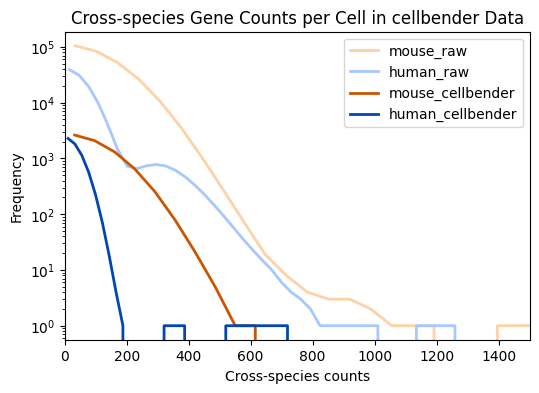

cellbender human cell mouse gene contamination AUC: 136480.39999999997
cellbender mouse cell human gene contamination AUC: 456481.7399999999


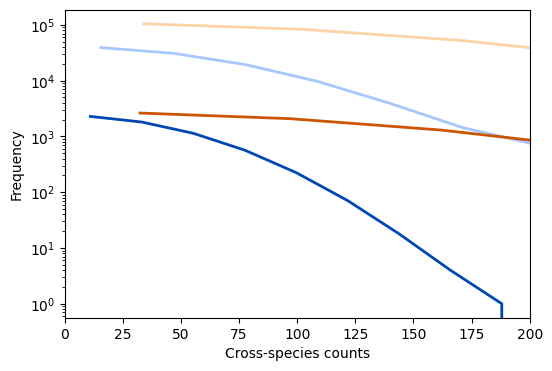

Contamination stats for soupx:
Mean human contamination counts (mouse reads in human cells): 0.21%
Mean mouse contamination counts (human reads in mouse cells): 1.22%
90th percentile human contamination counts (mouse reads in human cells): 0.27%
90th percentile mouse contamination counts (human reads in mouse cells): 2.03%
Total contamination across all human cells: 190,509
Total contamination across all mouse cells: 668,161
Total signal across all human cells: 113,798,282
Total signal across all mouse cells: 64,134,680
Human cell contamination removed: 1,392,706 (87.97% of raw)
Mouse cell contamination removed: 1,335,095 (66.65% of raw)
Human cell signal remaining: 113,798,282 (94.38% of raw)
Mouse cell signal remaining: 64,134,680 (95.79% of raw)
-----
soupx human cell mouse gene contamination AUC: 159154.52885133974
soupx mouse cell human gene contamination AUC: 392445.66104046814


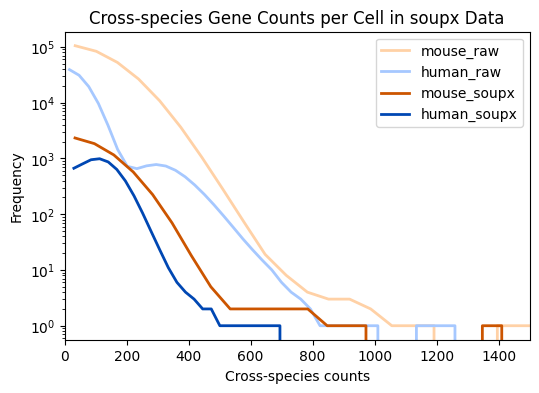

soupx human cell mouse gene contamination AUC: 159154.52885133974
soupx mouse cell human gene contamination AUC: 392445.66104046814


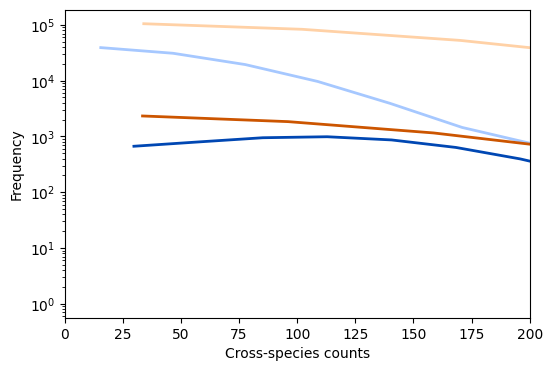

Contamination stats for decontx:
Mean human contamination counts (mouse reads in human cells): 0.45%
Mean mouse contamination counts (human reads in mouse cells): 0.98%
90th percentile human contamination counts (mouse reads in human cells): 0.27%
90th percentile mouse contamination counts (human reads in mouse cells): 0.97%
Total contamination across all human cells: 291,793
Total contamination across all mouse cells: 636,128
Total signal across all human cells: 113,432,443
Total signal across all mouse cells: 64,270,337
Human cell contamination removed: 1,291,422 (81.57% of raw)
Mouse cell contamination removed: 1,367,128 (68.25% of raw)
Human cell signal remaining: 113,432,443 (94.07% of raw)
Mouse cell signal remaining: 64,270,337 (96.00% of raw)
-----
decontx human cell mouse gene contamination AUC: 154694.48030655144
decontx mouse cell human gene contamination AUC: 11136.646347481092


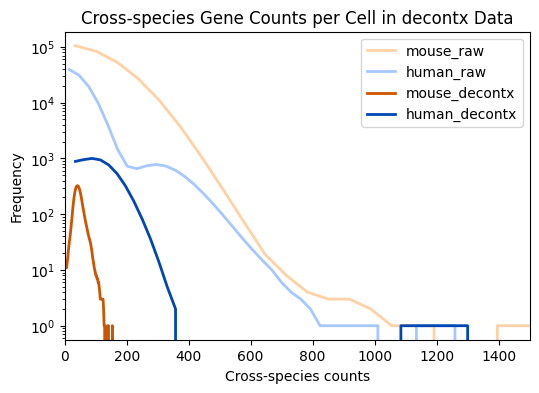

decontx human cell mouse gene contamination AUC: 154694.48030655144
decontx mouse cell human gene contamination AUC: 11136.646347481092


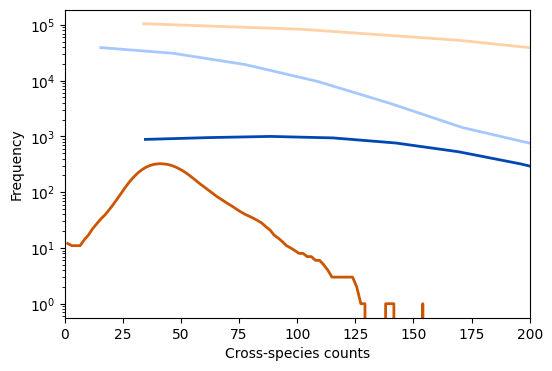

Contamination stats for scar:
Mean human contamination counts (mouse reads in human cells): 0.02%
Mean mouse contamination counts (human reads in mouse cells): 0.04%
90th percentile human contamination counts (mouse reads in human cells): 0.01%
90th percentile mouse contamination counts (human reads in mouse cells): 0.02%
Total contamination across all human cells: 17,667
Total contamination across all mouse cells: 22,817
Total signal across all human cells: 113,113,935
Total signal across all mouse cells: 63,455,805
Human cell contamination removed: 1,565,548 (98.88% of raw)
Mouse cell contamination removed: 1,980,439 (98.86% of raw)
Human cell signal remaining: 113,113,935 (93.81% of raw)
Mouse cell signal remaining: 63,455,805 (94.78% of raw)
-----
scar human cell mouse gene contamination AUC: 83604.30000000002
scar mouse cell human gene contamination AUC: 110136.31999999999


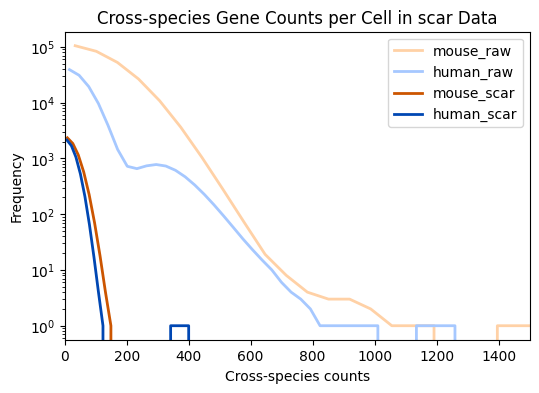

scar human cell mouse gene contamination AUC: 83604.30000000002
scar mouse cell human gene contamination AUC: 110136.31999999999


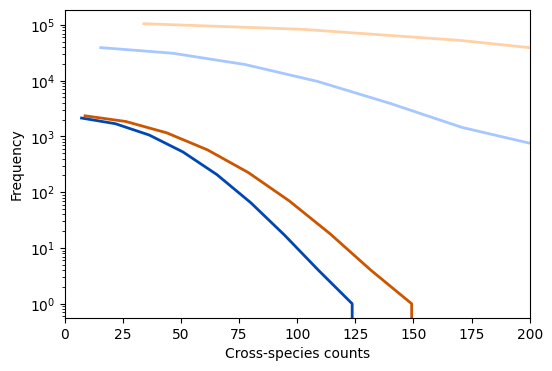

In [65]:
if dataset_name == "hgmm_12k":
    cell_sets = [
        set(adata.obs_names)
        for key, adata in adata_dict.items()
        if adata is not None and key != "raw"
    ]
    cells_common_to_all_tools = set.intersection(*cell_sets)
    
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cs_utils.identify_human_and_mouse_cells(adata_raw)  # adds mm10_total_counts, hg19_total_counts, genome to adata.obs
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()

    def print_contamination_stats(adata, doublet_cell_set=None, raw_mouse_cell_contamination=None, raw_human_cell_contamination=None, raw_mouse_cell_signal=None, raw_human_cell_signal=None):
        adata = adata.copy()
        if doublet_cell_set is not None:
            adata = adata[~adata.obs_names.isin(doublet_cell_set)].copy()
        if "genome" not in adata.obs.columns or "human_counts_total" not in adata.obs.columns or "mouse_counts_total" not in adata.obs.columns:
            adata = cs_utils.identify_human_and_mouse_cells(adata)  # adds human_counts_total, mouse_counts_total, genome to adata.obs
        adata.obs["total_counts"] = np.ravel(adata.X.sum(axis=1))
        adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"] = adata.obs["mouse_counts_total"] / adata.obs["total_counts"]
        adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"] = adata.obs["human_counts_total"] / adata.obs["total_counts"]

        mean_human_contamination_counts = adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"].mean()
        mean_mouse_contamination_counts = adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"].mean()

        # get 90th percentile
        human_contamination_counts_90th = adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"].quantile(0.9)
        mouse_contamination_counts_90th = adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"].quantile(0.9)

        human_cell_contamination = adata.obs.loc[adata.obs["genome"] == "hg19", "mouse_counts_total"].sum()
        mouse_cell_contamination = adata.obs.loc[adata.obs["genome"] == "mm10", "human_counts_total"].sum()
        human_cell_signal = adata.obs.loc[adata.obs["genome"] == "hg19", "human_counts_total"].sum()
        mouse_cell_signal = adata.obs.loc[adata.obs["genome"] == "mm10", "mouse_counts_total"].sum()

        # print as percentage rounded to 4 decimal places
        print(f"Mean human contamination counts (mouse reads in human cells): {mean_human_contamination_counts:.2%}")
        print(f"Mean mouse contamination counts (human reads in mouse cells): {mean_mouse_contamination_counts:.2%}")
        print(f"90th percentile human contamination counts (mouse reads in human cells): {human_contamination_counts_90th:.2%}")
        print(f"90th percentile mouse contamination counts (human reads in mouse cells): {mouse_contamination_counts_90th:.2%}")
        print(f"Total contamination across all human cells: {human_cell_contamination:,.0f}")
        print(f"Total contamination across all mouse cells: {mouse_cell_contamination:,.0f}")
        print(f"Total signal across all human cells: {human_cell_signal:,.0f}")
        print(f"Total signal across all mouse cells: {mouse_cell_signal:,.0f}")
        if raw_human_cell_contamination is not None and raw_mouse_cell_contamination is not None:
            human_contamination_removed = raw_human_cell_contamination - human_cell_contamination
            mouse_contamination_removed = raw_mouse_cell_contamination - mouse_cell_contamination
            print(f"Human cell contamination removed: {human_contamination_removed:,.0f} ({human_contamination_removed / raw_human_cell_contamination:.2%} of raw)")
            print(f"Mouse cell contamination removed: {mouse_contamination_removed:,.0f} ({mouse_contamination_removed / raw_mouse_cell_contamination:.2%} of raw)")
        if raw_human_cell_signal is not None and raw_mouse_cell_signal is not None:
            print(f"Human cell signal remaining: {human_cell_signal:,.0f} ({human_cell_signal / raw_human_cell_signal:.2%} of raw)")
            print(f"Mouse cell signal remaining: {mouse_cell_signal:,.0f} ({mouse_cell_signal / raw_mouse_cell_signal:.2%} of raw)")

        print("-----")

        return human_cell_contamination, mouse_cell_contamination, human_cell_signal, mouse_cell_signal

    raw_human_cell_contamination, raw_mouse_cell_contamination, raw_human_cell_signal, raw_mouse_cell_signal = None, None, None, None
    for key, adata_processed in adata_dict.items():
        print(f"Contamination stats for {key}:")
        human_cell_contamination, mouse_cell_contamination, human_cell_signal, mouse_cell_signal = print_contamination_stats(adata_processed, doublet_cell_set=doublet_cell_set, raw_human_cell_contamination=raw_human_cell_contamination, raw_mouse_cell_contamination=raw_mouse_cell_contamination, raw_human_cell_signal=raw_human_cell_signal, raw_mouse_cell_signal=raw_mouse_cell_signal)
        if key == "raw":
            raw_human_cell_contamination = human_cell_contamination
            raw_mouse_cell_contamination = mouse_cell_contamination
            raw_human_cell_signal = human_cell_signal
            raw_mouse_cell_signal = mouse_cell_signal

        if key == "raw" or adata_processed is None:
            continue

        adata_processed = adata_processed.copy()

        # add genome info to processed adata from raw
        if "genome" not in adata_processed.obs.columns:
            adata_processed.obs["genome"] = adata_raw.obs["genome"].reindex(adata_processed.obs_names)
            adata_dict[key] = adata_processed

        # plot histograms of human and mouse contamination
        cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, xmax=1_500, kind="smooth", out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_cells.png"))
        cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, xmax=200, kind="smooth", plot_legend=False, title=None, out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_cells_zoomed.png"))
        # cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, histogram_values="genes", xmax=35_000, out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_genes.png"))
        
        #!!!
        # # plot joint scatterplots
        # if key == "raw":
        #     continue
        # adata_processed = adata_processed[adata_processed.obs_names.isin(cells_common_to_all_tools)].copy()
        # cs_utils.plot_cross_species_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm_12k":
    sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_scanpy_dict = {}

for adata_name, adata in adata_dict.items():
    if adata_name == "raw":
        adata_scanpy_dict["raw"] = adata.copy()
        continue
    elif adata is None:
        continue

    adata = adata.copy()
    adata = cs_utils.run_scanpy_preprocessing_and_clustering(adata, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata = cs_utils.determine_cell_types(adata, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
    adata.X = adata.layers["counts"].copy()  # reset X to raw counts
    adata_scanpy_dict[adata_name] = adata.copy()

In [ ]:
# wompwomp_path = os.path.join(os.path.dirname(cellsweep_dir), "wompwomp")
# wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"

# # wrap in try-except block to catch errors due to wompwomp installation issues
# try:
#     adatas_alluvial_dict = OrderedDict(
#         (name, adata)
#         for name, adata in adata_scanpy_dict.items()
#         if name != "raw" and adata is not None
#     )
#     adatas_alluvial = [adata for adata in adatas_alluvial_dict.values()]
#     col_names_alluvial = list(adatas_alluvial_dict.keys())
#     out_path = os.path.join(out_dir, "alluvial_cluster.png")
#     cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
#     if os.path.exists(out_path):
#         display(Image(filename=out_path))

#     out_path = os.path.join(out_dir, "alluvial_celltype.png")
#     cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
#     if os.path.exists(out_path):
#         display(Image(filename=out_path))

# except Exception as e:
#     print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# print(models.models_description())
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    if model_pkl == "Immune_All_High.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_High_celltype_mapping
        celltype_mapping_correlation = CellTypistHigh_to_ImmuneMajor
    elif model_pkl == "Immune_All_Low.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_Low_celltype_mapping
        celltype_mapping_correlation = CellTypistLow_to_ImmuneMajor
    else:
        raise ValueError(f"Unknown model_pkl {model_pkl} for pbmc8k dataset.")
    
    reverse_map = {fine: broad for broad, fine_list in celltype_mapping.items() for fine in fine_list}
    for adata_name, adata in adata_scanpy_dict.items():
        if adata_name == "raw" or adata is None:
            continue
        adata = adata.copy()
        adata.obs["broad_celltype"] = adata.obs["celltype"].astype(str).map(reverse_map).fillna("Other")
        adata.obs["celltype_for_correlation"] = adata.obs["celltype"].astype(str).map(celltype_mapping_correlation).fillna("Other")
        adata_scanpy_dict[adata_name] = adata  # update original dict with broad cell types

### Remake CellBender Figure 2

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    marker_genes_cellbender_fig2 = cfg["marker_genes_cellbender_fig2"]
    if marker_genes_cellbender_fig2 is not None and len(marker_genes_cellbender_fig2) > 0:
        for adata_name, adata in adata_dict.items():
            if adata_name == "raw" or adata is None:
                continue
        
            adata = adata.copy()
        
            #* Standardize clusters to cellsweep
            adata.obs["leiden_cellsweep"] = adata_scanpy_dict["cellsweep"].obs["leiden"].reindex(adata.obs.index)
            adata = cs_utils.zero_out_low_counts(adata, threshold=0.5)  # zero out counts below 0.5

            plot_raw = (adata_name == "cellsweep")
            cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes_cellbender_fig2, plot_raw=plot_raw, cluster_column="leiden_cellsweep", log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot (cellsweep clusters)", title_processed=f"{adata_name} Processed Data Dotplot (cellsweep clusters)", out_path_raw=os.path.join(out_dir, "dotplot_raw_with_cellsweep_clusters_cellbender_fig2.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_with_cellsweep_clusters_cellbender_fig2.png"))

### Clusters 14-16 differ - which celltypes are these?

In [ ]:
# if dataset_name == "pbmc8k":
#     clusters_of_interest = [14, 15, 16]
#     for cluster in clusters_of_interest:
#         print(
#             (
#                 adata_scanpy_dict["cellsweep"]
#                 .obs
#                 .loc[adata_scanpy_dict["cellsweep"].obs["leiden_cellsweep"] == str(cluster), "celltype_for_correlation"]
#                 .value_counts()
#             )
#         )

Dendritic cells!

In [ ]:
# if dataset_name == "pbmc8k":
#     marker_genes_cellbender_fig2 = cfg["marker_genes_cellbender_fig2"]
#     if marker_genes_cellbender_fig2 is not None and len(marker_genes_cellbender_fig2) > 0:
#         for adata_name, adata in adata_scanpy_dict.items():
#             if adata_name == "raw" or adata is None:
#                 continue
            
#             adata = adata.copy()
        
#             #* Standardize clusters to cellsweep
#             if adata_name == "cellsweep":
#                 adata.obs["leiden_cellsweep"] = adata.obs["leiden"]
#             else:
#                 adata.obs["leiden_cellsweep"] = adata_scanpy_dict["cellsweep"].obs["leiden"].reindex(adata.obs.index)
#             adata_scanpy_dict[adata_name] = adata  # update original dict with leiden_cellsweep
                
#             adata = cs_utils.zero_out_low_counts(adata, threshold=0.5)  # zero out counts below 0.5
            
#             plot_raw = (adata_name == "cellsweep")
#             cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes_cellbender_fig2, plot_raw=plot_raw, cluster_column="celltype_for_correlation", log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot (cellsweep clusters)", title_processed=f"{adata_name} Processed Data Dotplot (cellsweep clusters)", out_path_raw=os.path.join(out_dir, "dotplot_raw_with_cellsweep_clusters_cellbender_fig2_stratified_by_celltype.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_with_cellsweep_clusters_cellbender_fig2_stratified_by_celltype.png"))

### Now custom dotplots

In [ ]:
# row_category = "celltype"  # "celltype", "cluster"
# if marker_genes is not None and len(marker_genes) > 0:
#     if row_category == "cluster":
#         for cluster_number in sorted(adata_cellsweep.obs["leiden"].unique().tolist(), key=lambda x: int(x)):
#             cluster_size = adata_cellsweep.obs["leiden"].value_counts().get(cluster_number, 0)
#             print(f"Number of cells in leiden cluster {cluster_number}: {cluster_size}")
#     elif row_category == "celltype":
#         for celltype in sorted(adata_cellsweep.obs["celltype"].unique().tolist()):
#             celltype_size = adata_cellsweep.obs["celltype"].value_counts().get(celltype, 0)
#             print(f"Number of cells in celltype {celltype}: {celltype_size}")
#     else:
#         raise ValueError(f"Unknown row_category {row_category}.")
    
#     for adata_name, adata in adata_scanpy_dict.items():
#         if adata_name == "raw" or adata is None:
#             continue
#         adata = cs_utils.zero_out_low_counts(adata, threshold=0.5)  # zero out counts below 0.5
#         # cs_utils.make_raw_and_processed_dotplots(adata_scanpy_dict["raw"], adata, marker_genes, plot_raw=True, log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot ({adata_name} clusters)", title_processed=f"{adata_name} Processed Data Dotplot ({adata_name} clusters)", out_path_raw=os.path.join(out_dir, f"dotplot_{adata_name}_raw.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}.png"))

#         # #* Standardize clusters to cellsweep
#         if row_category == "cluster":
#             if adata_name == "cellsweep":
#                 adata_cellsweep.obs["leiden_cellsweep"] = adata_cellsweep.obs["leiden"]
#             else:
#                 adata.obs["leiden_cellsweep"] = adata_cellsweep.obs["leiden"].reindex(adata.obs.index)
#             cluster_column = "leiden_cellsweep"
#         elif row_category == "celltype":
#             if (dataset_name == "pbmc8k" or dataset_name == "pbmc33k") and "celltype_for_correlation" in adata_cellsweep.obs.columns:
#                 cluster_column = "celltype_for_correlation"
#             else:
#                 cluster_column = "celltype"

#         plot_raw = (adata_name == "cellsweep")
#         # cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes, plot_raw=plot_raw, cluster_column="leiden_cellsweep", log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot (cellsweep clusters)", title_processed=f"{adata_name} Processed Data Dotplot (cellsweep clusters)", out_path_raw=os.path.join(out_dir, "dotplot_raw_with_cellsweep_clusters.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_with_cellsweep_clusters.png"))
#         cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes, plot_raw=plot_raw, cluster_column=cluster_column, log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot {cluster_column}", title_processed=f"{adata_name} Processed Data Dotplot {cluster_column}", out_path_raw=os.path.join(out_dir, f"dotplot_raw_{cluster_column}.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_{cluster_column}.png"))

### Investigate legend

In [ ]:
# if marker_genes is not None and len(marker_genes) > 0:
#     leiden_cellsweep_number = "11"
#     gene_name = "LYZ"

#     common_cells = adata_raw.obs_names.intersection(adata_cellsweep.obs_names)
#     adata_raw_only_cellcellsweep_cells = adata_raw[common_cells].copy()
#     adata_raw_only_cellcellsweep_cells.obs = adata_raw_only_cellcellsweep_cells.obs.join(adata_cellsweep.obs[["broad_celltype", "leiden_cellsweep"]], how='left')

#     expr_vals_raw = cs_utils.calculate_single_dot(adata_raw_only_cellcellsweep_cells, leiden_cellsweep_number, gene_name, dataset_label="Raw", cluster_column="leiden_cellsweep")
#     expr_vals_cellsweep = cs_utils.calculate_single_dot(adata_cellsweep, leiden_cellsweep_number, gene_name, dataset_label="Cellsweep", cluster_column="leiden_cellsweep")

#     cs_utils.plot_multiple_kdes(
#         expr_list=[expr_vals_raw, expr_vals_cellsweep],
#         labels=["Raw", "Cellsweep"],
#         colors=["blue", "orange"],
#         gene_name=gene_name,
#         title=f"KDE of {gene_name} Expression in Leiden Cluster {leiden_cellsweep_number}",
#         bw_adjust=0.5,
#         log=True
#     )

## Look only at the genes specific to monocytes: S100A8, S100A9, LYZ, CST3. Use PTPRC as a negative control.

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    monocyte_neutrophil_pdc_marker_genes = ["S100A8", "S100A9", "LYZ", "CST3"]
    housekeeping_genes = ["PTPRC"]
    monocyte_neutrophil_pdc_celltypes = ["Monocytes", "Neutrophils", "DC"]
    for key, adata_processed in adata_scanpy_dict.items():
        if key == "raw" or adata_processed is None:
            continue
        show = True  # (key == "cellsweep")

        adata_raw_original = adata_scanpy_dict["raw"].copy()
        adata_processed_original = adata_processed.copy()

        if "counts" in adata_processed_original.layers:
            adata_processed_original.X = adata_processed_original.layers["counts"].copy()

        if "celltype_for_correlation" not in adata_processed_original.obs.columns:
            adata_processed_original.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")

        # monocyte marker genes in non-monocyte clusters (should move)
        adata_processed = adata_processed_original[
            ~adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", log=False, logx=True, raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Non-monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_scatterplot.png"), show=show)

        # monocyte marker genes in monocyte clusters (should not move)
        adata_processed = adata_processed_original[
            adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_scatterplot.png"), show=show)

        # housekeeping genes in all cells (should not move)
        adata_processed = adata_processed_original[
            :,  # all rows/cells
            [g for g in housekeeping_genes if g in adata_processed_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_processed.obs["total_housekeeping_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()
        
        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in housekeeping_genes if g in adata_raw_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_raw_tmp.obs["total_housekeeping_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_housekeeping_expression"], metric="total_housekeeping_expression", raw_values=adata_raw_tmp.obs["total_housekeeping_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_housekeeping_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_housekeeping_expression"], adata2=adata_raw_tmp.obs["total_housekeeping_expression"], scale="log", point_type="custom", title="All cells, housekeeping genes", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_housekeeping_scatterplot.png"), show=show)

## Look at PBMC marker correlation

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    correlation_results, correlation_average_values = cs_utils.compute_pbmc_correlations(adata_dict)
    for tool_name, adata_processed in adata_dict.items():
        if tool_name == "raw" or adata_processed is None:
            continue
        
        show = True  # show = (tool_name == "cellsweep")
        cs_utils.plot_pbmc_correlation_scatterplot(correlation_average_values, tool_name=tool_name, out_path=os.path.join(out_dir, f"{tool_name}_pbmc_correlation_scatterplot.png"), show=show)

## How sensitive are we to celltype method? Let's compare to Leiden clustering

In [ ]:
if dataset_name == "pbmc8k":
    leiden_resolutions = [0.1, 0.5, 1.0, 1.5, 2.0, 5.0]
    for leiden_resolution in leiden_resolutions:
        print(f"Running cellsweep with leiden resolution {leiden_resolution}...")
        adata_path_cellsweep_leiden = f"{data_dir}/adata_cellsweep_leiden_{str(leiden_resolution).replace('.', '_')}.h5ad"
        cellsweep_log_file_leiden = os.path.join(out_dir, f"cellsweep_leiden_{str(leiden_resolution).replace('.', '_')}.log")

        if not os.path.exists(adata_path_cellsweep_leiden) or overwrite:
            adata = adata_raw.copy()
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].cat.add_categories(["empty"]).reindex(adata.obs.index).fillna("empty")
            adata_cellsweep_leiden = denoise_count_matrix(adata, adata_out=adata_path_cellsweep_leiden, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file_leiden)
        else:
            adata_cellsweep_leiden = cs_utils.load_adata(adata_path_cellsweep_leiden, verbose=verbose)

        adata_cellsweep_leiden = adata_cellsweep_leiden[~adata_cellsweep_leiden.obs["is_empty"]].copy()
        adata_cellsweep_leiden.var_names_make_unique()

        number_of_clusters = adata_cellsweep_leiden.obs["celltype"].nunique()
        print("Number of clusters:", number_of_clusters)
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_matrix_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_cell_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_gene_scatterplot.png"))

## Empty Droplet analysis

In [ ]:
if dataset_name == "pbmc8k":
    #* cellsweep - thresholding + > 10 counts
    adata_dict["cellsweep"].obs["n_counts"] = np.array(adata_dict["cellsweep"].X.sum(axis=1)).ravel()
    cellsweep_cellular_barcodes = set(
        adata_dict["cellsweep"].obs.index[
            adata_dict["cellsweep"].obs["n_counts"] > 10  # more than 10 counts
        ]
    )
    cellsweep_empty_barcodes = set(adata_dict["raw"].obs.index) - cellsweep_cellular_barcodes

    #* knee plot threshold
    knee_threshold_cellular_barcodes = set(adata_dict["raw"].obs.loc[~adata_dict["raw"].obs["is_empty"]].index)
    knee_threshold_empty_barcodes = set(adata_dict["raw"].obs.index) - knee_threshold_cellular_barcodes

    #* cellbender
    cellbender_cellular_barcodes, cellbender_empty_barcodes = None, None
    if adata_dict.get("cellbender") is not None:
        cellbender_cellular_barcodes = set(adata_dict["cellbender"].obs.index)
        cellbender_empty_barcodes = set(adata_dict["raw"].obs.index) - cellbender_cellular_barcodes

    #* emptydrops
    emptydrops_barcodes_file = os.path.join(data_dir, "emptydrops_barcodes.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        if rerun_tools:
            !{docker} run --rm \
                -w /home/ruser/work \
                -v {cellsweep_dir}:{rver_docker_workspace} \
                josephrich98/cellsweep_tutorials:decontx.0.1.0 \
                Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                    {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                    {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}
        else:
            emptydrops_barcodes_url = "https://caltech.box.com/shared/static/cntju7vi06swzapuy1vka33dffxjc9xl.txt"
            !wget -O {emptydrops_barcodes_file} {emptydrops_barcodes_url}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    emptydrops_empty_barcodes = set(adata_dict["raw"].obs.index) - emptydrops_cellular_barcodes

    upset_data_dict_empty_barcodes = {
        # "cellsweep": cellsweep_empty_barcodes,
        "UMI_thresholding": knee_threshold_empty_barcodes,
        "emptydrops": emptydrops_empty_barcodes,
        # "cellbender": cellbender_empty_barcodes if cellbender_empty_barcodes is not None else None,
    }

    _ = cs_utils.make_upset_plot(upset_data_dict_empty_barcodes, title="Empty barcodes", out_path=os.path.join(out_dir, "empty_barcodes_upset.png"))

    upset_data_dict_cellular_barcodes = {
        # "cellsweep": cellsweep_cellular_barcodes,
        "UMI_thresholding": knee_threshold_cellular_barcodes,
        "emptydrops": emptydrops_cellular_barcodes,
        # "cellbender": cellbender_cellular_barcodes if cellbender_cellular_barcodes is not None else None,
    }

    _ = cs_utils.make_upset_plot(upset_data_dict_cellular_barcodes, title="Cellular barcodes", out_path=os.path.join(out_dir, "cellular_barcodes_upset.png"))

    adata_cellsweep_empty_barcode_method_threshold = adata_dict["cellsweep"].copy()  # what we did earlier, without the >10 counts filter
    adata_raw_empty_barcode_method_emptydrops = adata_dict["raw"].copy()
    adata_raw_empty_barcode_method_emptydrops.obs["is_empty"] = ~adata_raw_empty_barcode_method_emptydrops.obs_names.isin(emptydrops_cellular_barcodes)
    
    adata_path_cellsweep_emptydrops = os.path.join(data_dir, "adata_cellsweep_emptydrops_empty_droplets.h5ad")
    cellsweep_log_file_emptydrops = os.path.join(out_dir, "cellsweep_emptydrops_empty_droplets.log")
    if not os.path.exists(adata_path_cellsweep_emptydrops) or overwrite:
        if "celltype" not in adata_raw_empty_barcode_method_emptydrops.obs.columns:
            adata_raw_empty_barcode_method_emptydrops = cs_utils.determine_cell_types(adata_raw_empty_barcode_method_emptydrops, model_pkl=model_pkl, filter_empty=True, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
        adata_cellsweep_empty_barcode_method_emptydrops = denoise_count_matrix(adata_raw_empty_barcode_method_emptydrops, adata_out=adata_path_cellsweep_emptydrops, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method=None, threads=threads, verbose=verbose, log_file=cellsweep_log_file_emptydrops)
    else:
        adata_cellsweep_empty_barcode_method_emptydrops = cs_utils.load_adata(adata_path_cellsweep_emptydrops, verbose=verbose)
    adata_cellsweep_empty_barcode_method_emptydrops = adata_cellsweep_empty_barcode_method_emptydrops[~adata_cellsweep_empty_barcode_method_emptydrops.obs["is_empty"]].copy()
    adata_cellsweep_empty_barcode_method_emptydrops.var_names_make_unique()

    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_matrix_scatterplot.png"))
    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_cell_scatterplot.png"))
    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_gene_scatterplot.png"))


## How many empty droplets do we need?

In [ ]:
# adata_cellsweep_unnormalized = ad.read_h5ad(adata_path_cellsweep)
# adata_cellsweep_unnormalized = adata_cellsweep_unnormalized[~adata_cellsweep_unnormalized.obs["is_empty"]].copy()
# adata_cellsweep_unnormalized.var_names_make_unique()

if dataset_name == "pbmc8k":
    empty_droplet_numbers = [1_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

    import random
    random.seed(42)
    done_max = True  # change to False if I want at most one negative-control plot showing all empty droplets
    for empty_droplet_number in sorted(empty_droplet_numbers):
        if empty_droplet_number >= adata_raw.obs["is_empty"].sum():
            if done_max:
                print(f"Reached maximum number of empty droplets: {adata_raw.obs['is_empty'].sum()}. Stopping cellsweep empty droplet number sweep.")
                break
            empty_droplet_number = adata_raw.obs["is_empty"].sum()
            done_max = True
        print(f"Running cellsweep with empty droplet number {empty_droplet_number}...")
        adata_path_cellsweep_empty_droplet = f"{data_dir}/adata_cellsweep_empty_droplet_{str(empty_droplet_number).replace('.', '_')}.h5ad"
        cellsweep_log_file_empty_droplet = os.path.join(out_dir, f"cellsweep_empty_droplet_{str(empty_droplet_number).replace('.', '_')}.log")

        if not os.path.exists(adata_path_cellsweep_empty_droplet) or overwrite:
            adata = adata_raw.copy()
            if "celltype" not in adata.obs.columns:
                adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
            # keep only "empty_droplet_number" empty droplets for clustering
            
            empty_droplet_barcodes = adata.obs.index[adata.obs["is_empty"]].tolist()
            if empty_droplet_number > len(empty_droplet_barcodes):
                print(f"Warning: requested empty_droplet_number {empty_droplet_number} exceeds available empty droplets {len(empty_droplet_barcodes)}. Using all available empty droplets.")
                continue
            selected_empty_droplet_barcodes = set(random.sample(empty_droplet_barcodes, empty_droplet_number))
            adata_tmp = adata[
                adata.obs.index.isin(
                    adata.obs.index[~adata.obs["is_empty"]].tolist() + list(selected_empty_droplet_barcodes)
                )
            ].copy()
            adata_cellsweep_empty_droplet = denoise_count_matrix(adata_tmp, adata_out=adata_path_cellsweep_empty_droplet, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file_empty_droplet)
        else:
            adata_cellsweep_empty_droplet = cs_utils.load_adata(adata_path_cellsweep_empty_droplet, verbose=verbose)

        adata_cellsweep_empty_droplet = adata_cellsweep_empty_droplet[~adata_cellsweep_empty_droplet.obs["is_empty"]].copy()
        adata_cellsweep_empty_droplet.var_names_make_unique()

        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets matrix scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_matrix_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets cell scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_cell_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets gene scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_gene_scatterplot.png"))

## Bonus: Number of parameters in cellsweep and CellBender

In [ ]:
cellsweep_parameters = cs_utils.count_cellsweep_parameters(cellsweep_log_file)
print(cellsweep_parameters)

In [ ]:
if "cellbender" in alternative_tools and os.path.exists(cellbender_ckpt):
    cellbender_parameters = cs_utils.count_cellbender_parameters(cellbender_ckpt)
    print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")